## Question 1

#### Imports

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

#### Clean and Load the Data

In [105]:
## (～￣▽￣)～ Okay, I have no idea what I am doing, but here I go!

# Load the data from file (update path if needed)
data = np.genfromtxt('cepheids.txt', names=True)
data["logP"]

array([0.564814, 0.571489, 0.578244, 0.584952, 0.609329, 0.635863,
       0.646934, 0.65039 , 0.666501, 0.687034, 0.712165, 0.726883,
       0.729678, 0.730685, 0.735997, 0.739882, 0.761428, 0.771201,
       0.786342, 0.807815, 0.821971, 0.82586 , 0.828997, 0.832958,
       0.846591, 0.85593 , 0.902584, 0.923352, 0.967448, 0.976878,
       0.980171, 0.98498 , 0.989194, 0.993131, 1.006497, 1.032868,
       1.036854, 1.039548, 1.052579, 1.065819, 1.101875, 1.108822,
       1.135867, 1.138459, 1.150646, 1.177138, 1.214482, 1.232334,
       1.233609, 1.234029, 1.256661, 1.276818, 1.29448 , 1.307927,
       1.309564, 1.339443, 1.361977, 1.364945, 1.370016, 1.414321,
       1.431915, 1.449158, 1.457818, 1.478624, 1.531857, 1.550816,
       1.58897 , 1.61742 , 1.652569, 1.708102, 1.837426])

In [107]:
f = open('cepheids.txt', "r")
print(f.read())

# ID      logP       d     Ïƒ(d)  (m-M)0  Ïƒ(m-M)   MB       MV       MI       MJ       MH       MK       WVI      WJK   E(B-V)   Î”Ï†
#SU-Cas   0.289884    418   12     8.10   0.06    -2.53    -2.97    -3.52    -3.82    -4.05    -4.08    -4.37    -4.25   0.259   0.000
#DT-Cyg   0.397804    621   30     8.97   0.11    -2.82    -3.32    -3.87    -4.25    -4.51    -4.54    -4.71    -4.75   0.040   0.030
#EV-Sct   0.490098   1766   82    11.24   0.10    -2.72    -3.21    -3.90    -4.19    -4.45    -4.46    -4.97    -4.64   0.655   0.045
#SZ-Tau   0.498166    558    6     8.73   0.02    -2.62    -3.16    -3.80    -4.18    -4.49    -4.53    -4.78    -4.77   0.295  -0.005
SS-Sct   0.564814   1000   33    10.00   0.07    -2.21    -2.83    -3.55    -3.92    -4.24    -4.27    -4.65    -4.51   0.325  -0.035
RT-Aur   0.571489    389    4     7.95   0.02    -2.16    -2.69    -3.30    -3.75    -4.01    -4.05    -4.23    -4.26   0.059   0.005
QZ-Nor   0.578244   1346   38    10.64   0.06    -2.00   

In [113]:
print(data.dtype.names)

('ID', 'logP', 'd', 'Ïƒd', 'mM0', 'ÏƒmM', 'MB', 'MV', 'MI', 'MJ', 'MH', 'MK', 'WVI', 'WJK', 'EBV', 'Î”Ï†')


In [7]:
data["MK"]

array([-4.27, -4.05, -4.12, -4.5 , -4.16, -4.79, -4.5 , -4.42, -4.47,
       -4.74, -4.93, -4.82, -4.84, -4.65, -5.42, -4.65, -4.67, -4.78,
       -5.52, -4.47, -5.29, -4.47, -5.02, -4.7 , -5.11, -5.1 , -5.37,
       -5.41, -5.9 , -5.17, -5.49, -5.71, -5.79, -5.63, -5.81, -5.76,
       -5.82, -5.7 , -5.74, -5.82, -5.89, -6.15, -6.15, -6.04, -6.23,
       -6.01, -6.53, -6.4 , -6.26, -6.7 , -6.74, -6.47, -6.66, -6.39,
       -6.49, -6.84, -6.58, -6.8 , -6.94, -6.88, -7.13, -7.12, -7.61,
       -7.44, -7.58, -7.53, -7.32, -7.82, -7.62, -8.19, -8.57])

In [27]:
data["EBV"]

array([0.325, 0.059, 0.263, 0.098, 0.235, 0.217, 0.06 , 0.196, 0.289,
       0.266, 0.299, 0.3  , 0.072, 0.722, 0.336, 0.294, 0.188, 0.737,
       0.589, 0.521, 0.281, 0.166, 0.402, 0.397, 0.36 , 0.129, 0.603,
       0.099, 0.347, 0.486, 0.281, 0.14 , 0.179, 0.051, 0.014, 1.157,
       0.37 , 0.271, 0.322, 0.404, 0.857, 0.952, 0.416, 0.435, 0.462,
       0.439, 0.228, 0.493, 0.647, 0.534, 0.57 , 0.242, 0.911, 0.718,
       0.3  , 0.435, 0.372, 0.455, 0.344, 0.421, 0.179, 0.545, 0.869,
       0.518, 0.791, 0.146, 0.263, 0.457, 0.462, 1.31 , 0.787])

In [117]:
data['ÏƒmM']

array([0.07, 0.02, 0.06, 0.05, 0.03, 0.03, 0.02, 0.06, 0.02, 0.04, 0.05,
       0.03, 0.04, 0.03, 0.04, 0.07, 0.07, 0.07, 0.05, 0.09, 0.03, 0.04,
       0.02, 0.07, 0.07, 0.09, 0.04, 0.05, 0.04, 0.04, 0.03, 0.04, 0.02,
       0.03, 0.05, 0.1 , 0.05, 0.03, 0.1 , 0.09, 0.07, 0.15, 0.05, 0.03,
       0.05, 0.04, 0.02, 0.04, 0.03, 0.03, 0.05, 0.03, 0.04, 0.03, 0.02,
       0.04, 0.07, 0.02, 0.03, 0.02, 0.03, 0.03, 0.07, 0.04, 0.05, 0.02,
       0.03, 0.04, 0.02, 0.03, 0.03])

In [144]:
# Extract relevant columns
logP = data['logP']
MK = data['MK']
sigma = data['ÏƒmM']  # Corresponds to σ(m-M)
                      # щ(゜ロ゜щ) Don't ask me why 
                      # my computer formatted the sigma this way.

# print(data.dtype.names)
# sigma = data['σmM']  # Wrong
# sigma = data['sigma_m_M']  # Replace with actual column name

In [123]:
# Remove NaNs
valid = ~np.isnan(logP) & ~np.isnan(MK) & ~np.isnan(sigma)
logP = logP[valid]
MK = MK[valid]
sigma = sigma[valid]

#### Generalized Least Square

In [126]:
# Define the design matrix A for the model: M = a*(logP - 1.0) + b
x = logP - 1.0
A = np.vstack([x, np.ones_like(x)]).T

print(x)
print(A)

[-0.435186 -0.428511 -0.421756 -0.415048 -0.390671 -0.364137 -0.353066
 -0.34961  -0.333499 -0.312966 -0.287835 -0.273117 -0.270322 -0.269315
 -0.264003 -0.260118 -0.238572 -0.228799 -0.213658 -0.192185 -0.178029
 -0.17414  -0.171003 -0.167042 -0.153409 -0.14407  -0.097416 -0.076648
 -0.032552 -0.023122 -0.019829 -0.01502  -0.010806 -0.006869  0.006497
  0.032868  0.036854  0.039548  0.052579  0.065819  0.101875  0.108822
  0.135867  0.138459  0.150646  0.177138  0.214482  0.232334  0.233609
  0.234029  0.256661  0.276818  0.29448   0.307927  0.309564  0.339443
  0.361977  0.364945  0.370016  0.414321  0.431915  0.449158  0.457818
  0.478624  0.531857  0.550816  0.58897   0.61742   0.652569  0.708102
  0.837426]
[[-0.435186  1.      ]
 [-0.428511  1.      ]
 [-0.421756  1.      ]
 [-0.415048  1.      ]
 [-0.390671  1.      ]
 [-0.364137  1.      ]
 [-0.353066  1.      ]
 [-0.34961   1.      ]
 [-0.333499  1.      ]
 [-0.312966  1.      ]
 [-0.287835  1.      ]
 [-0.273117  1.      ]
 [

In [128]:
# Construct the weight matrix W
W = np.diag(1.0 / sigma**2)
W

array([[ 204.08163265,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [   0.        , 2500.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [   0.        ,    0.        ,  277.77777778, ...,    0.        ,
           0.        ,    0.        ],
       ...,
       [   0.        ,    0.        ,    0.        , ..., 2500.        ,
           0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
        1111.11111111,    0.        ],
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
           0.        , 1111.11111111]])

In [130]:
# Perform the weighted least squares fit
W = np.diag(1.0 / sigma**2)
ATW = A.T @ W
C = np.linalg.inv(ATW @ A)
params = C @ ATW @ MK
a, b = params

#### Fit Parameters

In [133]:
# Uncertainties in the fit parameters
sigma_a = np.sqrt(C[0, 0])
sigma_b = np.sqrt(C[1, 1])

# Print results
print(f"Fit parameters:")
print(f"a = {a:.4f} ± {sigma_a:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")

Fit parameters:
a = -3.2897 ± 0.0113
b = -5.6456 ± 0.0041


#### Plot and Interpolation:

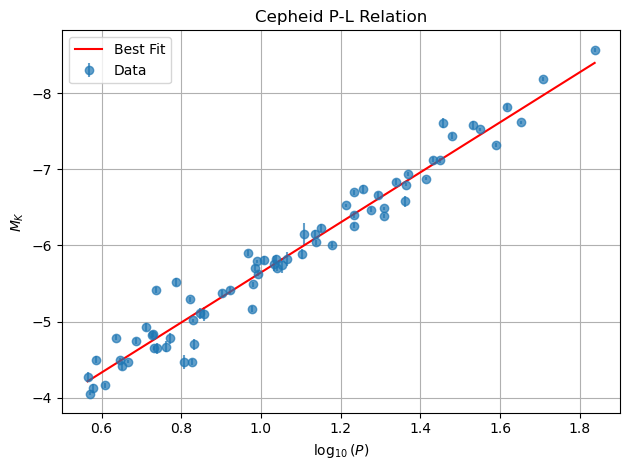

In [140]:
# Plotting
plt.errorbar(logP, MK, yerr=sigma, fmt='o', label='Data', alpha=0.7)
x_fit = np.linspace(min(logP), max(logP), 100)
M_fit = a * (x_fit - 1.0) + b
plt.plot(x_fit, M_fit, 'r-', label='Best Fit')
plt.xlabel('$\\log_{10}(P)$')
plt.ylabel(r'$M_K$')
plt.title('Cepheid P-L Relation')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [138]:
# Interpolation
interp_func = interp1d(x_fit, M_fit, kind='linear', fill_value='extrapolate')
new_logP = np.array([0.5, 1.0, 1.5])
estimated_MK = interp_func(new_logP)

for lp, mk in zip(new_logP, estimated_MK):
    print(f"logP = {lp:.2f} -> Estimated M_K = {mk:.3f}")

logP = 0.50 -> Estimated M_K = -4.001
logP = 1.00 -> Estimated M_K = -5.646
logP = 1.50 -> Estimated M_K = -7.290


## Question 2

#### Imports:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#### Functions:

In [ ]:
# Given reaction rate function
def lambda_T(T):
    T8 = T / 1e8
    return 5.09e11 * T8**(-3) * np.exp(-44.027 / T8)

# Lagrange interpolation function for 4 points
def lagrange_interp(x_vals, y_vals, x):
    result = 0.0
    for i in range(4):
        term = y_vals[i]
        for j in range(4):
            if i != j:
                term *= (x - x_vals[j]) / (x_vals[i] - x_vals[j])
        result += term
    return result

#### I have no idea what to name this section (o゜▽゜)o☆

In [ ]:
# 1. Sample log10 T values
logT_samples = np.linspace(np.log10(1e8), np.log10(5e9), 10)
T_samples = 10**logT_samples
log_lambda_samples = np.log10(lambda_T(T_samples))

# 2. Randomly choose 25 T values in same range
T_random = 10**np.random.uniform(np.log10(1e8), np.log10(5e9), 25)
logT_random = np.log10(T_random)

errors = []
log_lambda_interp_all = []
log_lambda_true_all = []

# 3. Interpolate for each random T
for logT0 in logT_random:
    # Find index of closest point
    idx = np.searchsorted(logT_samples, logT0) - 1
    idx = np.clip(idx, 1, len(logT_samples) - 3)

    # Grab 4 surrounding points
    x_vals = logT_samples[idx-1:idx+3]
    y_vals = log_lambda_samples[idx-1:idx+3]

    # Interpolate
    log_lambda_interp = lagrange_interp(x_vals, y_vals, logT0)
    log_lambda_interp_all.append(log_lambda_interp)

    # Compute true value
    lambda_true = lambda_T(10**logT0)
    log_lambda_true = np.log10(lambda_true)
    log_lambda_true_all.append(log_lambda_true)

    error = abs(log_lambda_interp - log_lambda_true)
    errors.append(error)

# 4. Report max error
max_error = max(errors)
print(f"Max interpolation error in log10(lambda): {max_error:.5e}")

#### Plot!

In [ ]:
# 5. Plotting comparison of true vs interpolated values
plt.figure(figsize=(8, 6))
plt.plot(logT_random, log_lambda_true_all, 'o', label='True log10(lambda)', alpha=0.7)
plt.plot(logT_random, log_lambda_interp_all, 'x', label='Interpolated log10(lambda)', alpha=0.7)
plt.xlabel('log10(T)')
plt.ylabel('log10(lambda)')
plt.title('Comparison of True vs Interpolated log10(lambda)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 6. Plotting absolute error
plt.figure(figsize=(10, 5))
plt.plot(logT_random, errors, 's', color='red', alpha=0.6)
plt.xlabel('log10(T)')
plt.ylabel('Absolute Error in log10(lambda)')
plt.title('Interpolation Error vs log10(T)')
plt.grid(True)
plt.show()

I do not know if this is going to be necessary, but! ᕦ(ò_óˇ)ᕤ
#### Full comparison with scipy!

#### Import:

In [ ]:
from scipy.interpolate import lagrange as scipy_lagrange

In [ ]:
poly = scipy_lagrange(logT_samples, log_lambda_samples)
log_lambda_full_interp_all = poly(logT_random)

In [ ]:
# Plotting full interpolation comparison
plt.figure(figsize=(10, 6))
plt.plot(logT_random, log_lambda_true_all, 'o', label='True log10(lambda)', alpha=0.6)
plt.plot(logT_random, log_lambda_full_interp_all, '^', label='Full Lagrange Interpolation', alpha=0.6)
plt.xlabel('log10(T)')
plt.ylabel('log10(lambda)')
plt.title('True vs Full Lagrange Interpolation')
plt.legend()
plt.grid(True)
plt.show()